In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data_original = pd.read_csv('dataset.csv')

df = data_original.copy()
df.head()

df = df.drop('id', axis=1)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    str    
 6   pc              335 non-null    str    
 7   pcc             396 non-null    str    
 8   ba              396 non-null    str    
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    str    
 16  wc              295 non-null    str    
 17  rc              270 non-null    str    
 18  h

In [3]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()
    
df = df.replace('?', np.nan)

/tmp/ipykernel_87188/753698638.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [4]:
for col in df.columns:
    
    print(col)
    print(df[col].unique())
    print('======================================================================')

age
[48.  7. 62. 51. 60. 68. 24. 52. 53. 50. 63. 40. 47. 61. 21. 42. 75. 69.
 nan 73. 70. 65. 76. 72. 82. 46. 45. 35. 54. 11. 59. 67. 15. 55. 44. 26.
 64. 56.  5. 74. 38. 58. 71. 34. 17. 12. 43. 41. 57.  8. 39. 66. 81. 14.
 27. 83. 30.  4.  3.  6. 32. 80. 49. 90. 78. 19.  2. 33. 36. 37. 23. 25.
 20. 29. 28. 22. 79.]
bp
[ 80.  50.  70.  90.  nan 100.  60. 110. 140. 180. 120.]
sg
[1.02  1.01  1.005 1.015   nan 1.025]
al
[ 1.  4.  2.  3.  0. nan  5.]
su
[ 0.  3.  4.  1. nan  2.  5.]
rbc
<StringArray>
[nan, 'normal', 'abnormal']
Length: 3, dtype: str
pc
<StringArray>
['normal', 'abnormal', nan]
Length: 3, dtype: str
pcc
<StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
ba
<StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
bgr
[121.  nan 423. 117. 106.  74. 100. 410. 138.  70. 490. 380. 208.  98.
 157.  76.  99. 114. 263. 173.  95. 108. 156. 264. 123.  93. 107. 159.
 140. 171. 270.  92. 137. 204.  79. 207. 124. 144.  91. 162. 246. 253.
 141. 182.  86. 150. 1

In [5]:
cols = ['pcv','wc','rc']

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [6]:
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())

    else:
        df[col] = df[col].fillna(df[col].mode()[0])
        
df = pd.get_dummies(df, drop_first=True)


classification_notckd
False    250
True     150
Name: count, dtype: int64

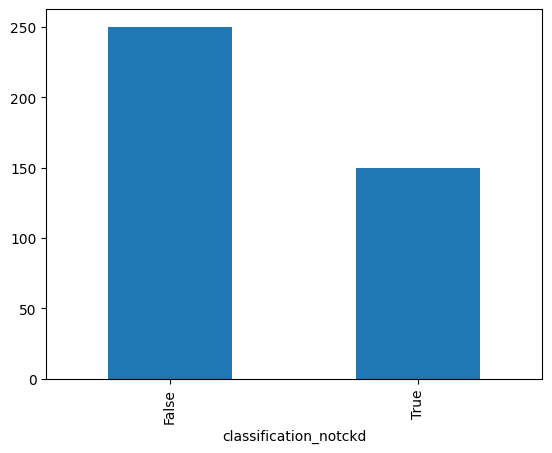

In [7]:
df['classification_notckd'].value_counts().plot(kind='bar')

df['classification_notckd'].value_counts()

In [8]:
x = df.drop('classification_notckd', axis=1)
y = df['classification_notckd']

Correlation of features with purpose

In [9]:
correlations = x.corrwith(y).sort_values(ascending=False)
print("strength of correlation with target variable:")
print(correlations.head(10))

strength of correlation with target variable:
hemo          0.729628
sg            0.698957
pcv           0.690060
rc            0.590913
pc_normal     0.375154
sod           0.342288
rbc_normal    0.282642
pot          -0.076921
ba_present   -0.186871
wc           -0.205274
dtype: float64


What features had the most Missing Value?

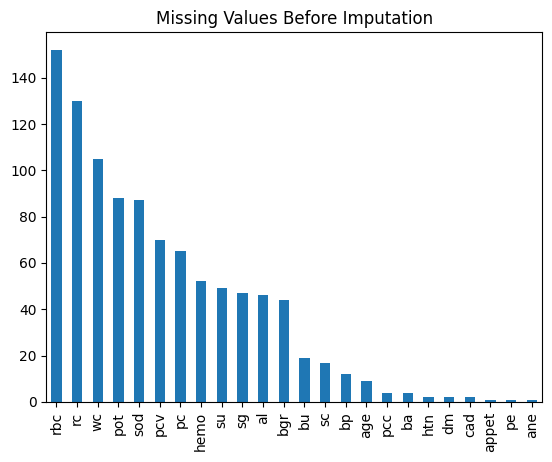

In [10]:
missing_before = data_original.isnull().sum()
missing_before[missing_before > 0].sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values Before Imputation')
plt.show()

Comparison of age distribution in patients and healthy people

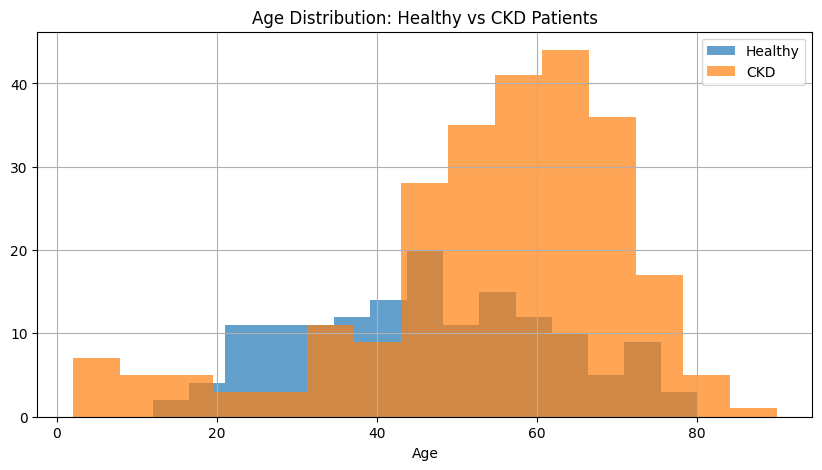

In [11]:
plt.figure(figsize=(10, 5))

df[df['classification_notckd']==1]['age'].hist(alpha=0.7, label='Healthy', bins=15)

df[df['classification_notckd']==0]['age'].hist(alpha=0.7, label='CKD', bins=15)

plt.legend()

plt.title('Age Distribution: Healthy vs CKD Patients')
plt.xlabel('Age')
plt.show()

In [12]:


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scale', StandardScaler()),
    ('model', svm.SVC(kernel='rbf'))
])


pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)


print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


0.9875
              precision    recall  f1-score   support

       False       1.00      0.98      0.99        52
        True       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



For Test User:

In [13]:
for col in df.columns:
    if pd.api.types.is_bool_dtype(df[col]):
        print(f"{col} 0/1:")

rbc_normal 0/1:
pc_normal 0/1:
pcc_present 0/1:
ba_present 0/1:
htn_yes 0/1:
dm_yes 0/1:
cad_yes 0/1:
appet_poor 0/1:
pe_yes 0/1:
ane_yes 0/1:
classification_notckd 0/1:
